```text
First LGD experiments
├── Import & Setup
├── Limitation
├── Explore
├── Pre-processing
└── LGD estimation   
    ├── Fit & Evaluate
    ├── Transform
    └── Export
```

#### Import & Setup 

In [1]:
# Init work dir

from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# Standard modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Framework

from src.feature_engineering import create_target_def12, SpecialMappings
from src.metrics import my_regression_metrics
from src.modelling import fit_lgd, transform_lgd
from src.plots import compare_lgd_distributions, explore_variable, pred_vs_obs_lgd, variable_vs_lgd  
from src.preprocessing import my_input_load, my_time_split, ReplaceMinusOne
from src.validation import model_selector, missing_summary

# ML modules

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Configuration

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)
from sklearn import set_config; set_config(transform_output="pandas") # set sklearn output: pandas

In [3]:
# load input file

full_dataset = my_input_load(2019, 2020)

# create def12

full_dataset, dr_summary = create_target_def12(full_dataset)

# split train/test

windows = {"train": (2019, 2019), "test":  (2020, 2020)}

splits = my_time_split(full_dataset, "LoanYear", windows)

ds_trai = splits["train"]["df"]
ds_test = splits["test"]["df"]

LoanDate range:     2019-01-01 00:00:00 2020-12-31 00:00:00
+12 months:         2020-01-01 00:00:00 2021-12-31 00:00:00
DefaultDate range:  2019-04-26 00:00:00 2023-10-13 00:00:00


LoanYear,num_loans,num_defaults,default_rate
2019,28487,4879,0.171271
2020,19959,2294,0.114936



SPLIT SUMMARY

TRAIN
Years        : 2019 - 2019
Shape (X, y) : (28487, 105), (28487,)

LoanYear distribution
LoanYear
2019    28487
Name: count, dtype: int64

Default rate : 0.1713
------------------------------------------------------------

TEST
Years        : 2020 - 2020
Shape (X, y) : (19959, 105), (19959,)

LoanYear distribution
LoanYear
2020    19959
Name: count, dtype: int64

Default rate : 0.1149
------------------------------------------------------------


#### Limitation


Analysis reveals a structural change in the LossGivenDefault variable across loan origination years. While the period **2019–2020** contains zero-loss observations (full-recoveries), earlier and later years show higher and constrained LGD values, suggesting differences in the underlying target definition or calculation methodology. Since the objective of this project is to demonstrate a modular LGD estimation rather than validate the dataset itself, **LossGivenDefault is treated as the observed target variable**, and the LGD models are developed on the 2019–2020 period, where the target behaves consistently. A simplified univariate model based on **Amount** is chosen and LGD modelling will be revisited at a later stage.

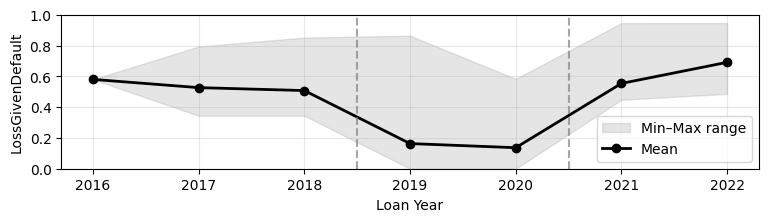

In [4]:
# explore "LossGivenDefault" across years

explore_variable(variable="LossGivenDefault", yr_start=2016, yr_end=2022, breaks=[2018.5, 2020.5])

#### Explore

In [5]:
# explore lgd & recovery

columns_to_explore = [
    "Age",
    "Gender",
    "Amount",
    "Interest",
    "LoanDuration",
    "Education",
    "EmploymentDurationCurrentEmployer",
    "HomeOwnershipType",
    "IncomeTotal",
    "ExistingLiabilities",
    "LiabilitiesTotal",
    "CreditScoreEeMini",
    "NoOfPreviousLoansBeforeLoan",
    "AmountOfPreviousLoansBeforeLoan",
    "PreviousRepaymentsBeforeLoan"
]

for variable in columns_to_explore:
    if splits["train"]["df"][variable].nunique() <= 20:
        print(variable)
        variable_vs_lgd(splits["train"]["df"], variable)

Gender


,Gender,count,LGD(mean),LGD=0,LGD>0,Recovery(%)
0,0.000000,3486,0.224,1950,1536,55.938
1,1.000000,1393,0.067,1234,159,88.586


LoanDuration


,LoanDuration,count,LGD(mean),LGD=0,LGD>0,Recovery(%)
0,6,7,0.059,6,1,85.714
1,9,12,0.000,12,0,100.000
2,12,20,0.158,13,7,65.000
3,18,29,0.033,27,2,93.103
4,24,45,0.150,31,14,68.889
5,30,41,0.127,31,10,75.610
6,36,2007,0.183,1261,746,62.830
7,48,197,0.197,119,78,60.406
8,60,2521,0.179,1684,837,66.799


Education


...

,EmploymentDurationCurrentEmployer,count,LGD(mean),LGD=0,LGD>0,Recovery(%)
0,MoreThan5Years,1234,0.192,767,467,62.156
1,Other,248,0.159,172,76,69.355
2,Retiree,277,0.198,175,102,63.177
3,TrialPeriod,17,0.375,5,12,29.412
4,UpTo1Year,1343,0.186,870,473,64.780
5,UpTo2Years,59,0.242,30,29,50.847
6,UpTo3Years,44,0.252,21,23,47.727
7,UpTo4Years,13,0.259,6,7,46.154
8,UpTo5Years,1644,0.158,1138,506,69.221


HomeOwnershipType


,HomeOwnershipType,count,LGD(mean),LGD=0,LGD>0,Recovery(%)
0,1.000000,1774,0.191,1120,654,63.134
1,2.000000,1108,0.176,737,371,66.516
2,3.000000,1149,0.158,802,347,69.800
3,4.000000,24,0.271,11,13,45.833
4,5.000000,58,0.228,33,25,56.897
5,6.000000,14,0.338,5,9,35.714
6,7.000000,28,0.338,9,19,32.143
7,8.000000,212,0.193,118,94,55.660
8,9.000000,5,0.323,1,4,20.000
9,10.000000,507,0.165,348,159,68.639


CreditScoreEeMini


,CreditScoreEeMini,count,LGD(mean),LGD=0,LGD>0,Recovery(%)
0,500.000000,21,0.118,16,5,76.190
1,600.000000,244,0.138,173,71,70.902
2,700.000000,258,0.172,176,82,68.217
3,800.000000,601,0.164,419,182,69.717
4,900.000000,393,0.187,257,136,65.394
5,1000.000000,3362,0.185,2143,1219,63.742


#### Pre-processing

In [6]:
# load input file

columns_to_use = [
    "LossGivenDefault", # the target here
    "DefaultDate", # needed
    "FirstPaymentDate", # needed
    "LoanApplicationStartedDate", # needed
    "LoanDate", # needed
    "Country", # needed
    "Age",
    "Gender",
    "Amount",
    "Interest",
    "LoanDuration",
    "Education",
    "EmploymentDurationCurrentEmployer",
    "HomeOwnershipType",
    "IncomeTotal",
    "ExistingLiabilities",
    "LiabilitiesTotal",
    "CreditScoreEeMini",
    "NoOfPreviousLoansBeforeLoan",
    "AmountOfPreviousLoansBeforeLoan",
    "PreviousRepaymentsBeforeLoan",
    #"EmploymentStatus", empty
    "LanguageCode",
    #"MaritalStatus", empty
    "NewCreditCustomer", 
    #"OccupationArea", empty   
    #"UseOfLoan", empty        
    "VerificationType",
]

full_dataset = my_input_load(2019, 2020, columns_to_use=columns_to_use)

In [7]:
# CREATE def12 VARIABLE

full_dataset, dr_summary = create_target_def12(full_dataset)

LoanDate range:     2019-01-01 00:00:00 2020-12-31 00:00:00
+12 months:         2020-01-01 00:00:00 2021-12-31 00:00:00
DefaultDate range:  2019-04-26 00:00:00 2023-10-13 00:00:00


LoanYear,num_loans,num_defaults,default_rate
2019,28487,4879,0.171271
2020,19959,2294,0.114936


In [8]:
# TRAIN/TEST SPLIT

windows = {"train": (2019, 2019), "test":  (2020, 2020)}

splits = my_time_split(full_dataset, "LoanYear", windows, target="LossGivenDefault")

X_trai = splits["train"]["X"]
y_trai = splits["train"]["y"]
X_test = splits["test"]["X"]
y_test = splits["test"]["y"]


SPLIT SUMMARY

TRAIN
Years        : 2019 - 2019
Shape (X, y) : (28487, 19), (28487,)

LoanYear distribution
LoanYear
2019    28487
Name: count, dtype: int64

Default rate : 0.1633
------------------------------------------------------------

TEST
Years        : 2020 - 2020
Shape (X, y) : (19959, 19), (19959,)

LoanYear distribution
LoanYear
2020    19959
Name: count, dtype: int64

Default rate : 0.1365
------------------------------------------------------------


In [9]:
# DEFINE PURE CATEGORICAL VARIABLES

categorical_variables = [
    "Education",         # 1,2,3,4,5
    #"EmploymentStatus",  # 1,2,3,4,5,6
    "Gender",            # 0,1,2
    "HomeOwnershipType", # 0-10
    "LanguageCode",      # 1,2,3,4,5,6,9
    #"MaritalStatus",     # 1-5
    "NewCreditCustomer", # 0,1
    #"OccupationArea",    # 1-19
    #"UseOfLoan",         # 0-8
    "VerificationType"   # 0-4
]

for col in categorical_variables:
    X_trai[col] = X_trai[col].astype("category")
    X_test[col] = X_test[col].astype("category")

# separate nums/cats
cat_cols = X_trai.select_dtypes(include=["category"]).columns
num_cols = X_trai.select_dtypes(exclude=["category"]).columns

In [10]:
# -------------------------------------------------
# PREPROCESSOR FOR EMPIRICAL ESTIMATORS
# -------------------------------------------------

# numerical branch
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# categorical branch
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

# empirical preprocessor
preprocessor_empirical = Pipeline([
    ("replace_minus_one", ReplaceMinusOne(verbose=False)),
    ("special_mappings", SpecialMappings(verbose=False)),
    ("features", ColumnTransformer([
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols)
    ]))
])

# fit transform
X_trai_emp = preprocessor_empirical.fit_transform(X_trai)
X_test_emp = preprocessor_empirical.transform(X_test)

# merge with target
ds_trai_emp = pd.concat([X_trai_emp, y_trai], axis=1)
ds_test_emp = pd.concat([X_test_emp, y_test], axis=1)

In [11]:
# -------------------------------------------------
# PREPROCESSOR FOR MODEL ESTIMATORS
# -------------------------------------------------

# numerical branch
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# categorical branch
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        drop="first",
        sparse_output=False
    ))
])

# ML preprocessor
preprocessor_model = Pipeline([
    ("replace_minus_one", ReplaceMinusOne(verbose=True)),
    ("special_mappings", SpecialMappings()),
    ("features", ColumnTransformer([
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols)
    ]))
])

# fit transform
X_trai_mod = preprocessor_model.fit_transform(X_trai) 
X_test_mod = preprocessor_model.transform(X_test)

# merge with target
ds_trai_mod = pd.concat([X_trai_mod, y_trai], axis=1)
ds_test_mod = pd.concat([X_test_mod, y_test], axis=1)

/Users/konstantinoskazanas/Downloads/DATA SCIENCE/MLenv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [12]:
# check sizes

print(ds_trai_emp.shape)
print(ds_test_emp.shape)
print(ds_trai_mod.shape)
print(ds_test_mod.shape)

# check columns

print(ds_trai_emp.columns)
print(ds_trai_mod.columns)

(28487, 20)
(19959, 20)
(28487, 34)
(19959, 34)
Index(['num__Age', 'num__Amount', 'num__AmountOfPreviousLoansBeforeLoan',
       'num__CreditScoreEeMini', 'num__EmploymentDurationCurrentEmployer',
       'num__ExistingLiabilities', 'num__IncomeTotal', 'num__Interest',
       'num__LiabilitiesTotal', 'num__LoanDuration',
       'num__NoOfPreviousLoansBeforeLoan', 'num__PreviousRepaymentsBeforeLoan',
       'num__default12', 'cat__Education', 'cat__Gender',
       'cat__HomeOwnershipType', 'cat__LanguageCode', 'cat__NewCreditCustomer',
       'cat__VerificationType', 'LossGivenDefault'],
      dtype='str')
Index(['num__Age', 'num__Amount', 'num__AmountOfPreviousLoansBeforeLoan',
       'num__CreditScoreEeMini', 'num__EmploymentDurationCurrentEmployer',
       'num__ExistingLiabilities', 'num__IncomeTotal', 'num__Interest',
       'num__LiabilitiesTotal', 'num__LoanDuration',
       'num__NoOfPreviousLoansBeforeLoan', 'num__PreviousRepaymentsBeforeLoan',
       'num__default12', 'cat__Edu

## LGD estimation

#### Fit & Evaluate [empirical estimators]

In [13]:
# initialise experiments

experiments = [
    ("experiment A", "historical_avg", None),
    ("experiment B", "univariate", "num__Age"),
    ("experiment C", "univariate", "cat__Gender"),
    ("experiment D", "univariate", "num__Amount"),
    ("experiment E", "univariate", "num__Interest"),
    ("experiment F", "univariate", "num__LoanDuration"),
    ("experiment G", "univariate", "cat__Education"),
    ("experiment H", "univariate", "num__EmploymentDurationCurrentEmployer"),
    ("experiment I", "univariate", "cat__HomeOwnershipType"),
    ("experiment J", "univariate", "num__IncomeTotal"),
    ("experiment K", "univariate", "num__ExistingLiabilities"),
    ("experiment L", "univariate", "num__LiabilitiesTotal"),
    ("experiment M", "univariate", "num__CreditScoreEeMini"),
    ("experiment N", "univariate", "num__NoOfPreviousLoansBeforeLoan"),
    ("experiment O", "univariate", "num__AmountOfPreviousLoansBeforeLoan"),
]

experiment_metrics = []

LGD estimation method: historical_avg


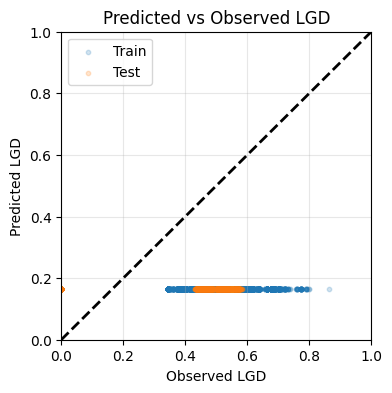

LGD estimation method: univariate
Feature: num__Age


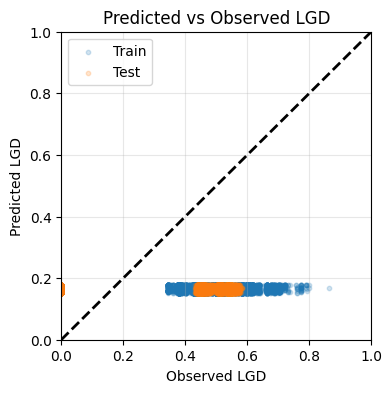

LGD estimation method: univariate
Feature: cat__Gender


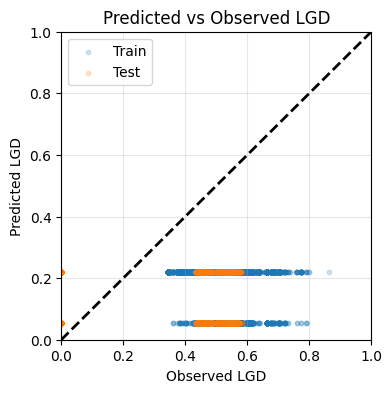

LGD estimation method: univariate
Feature: num__Amount


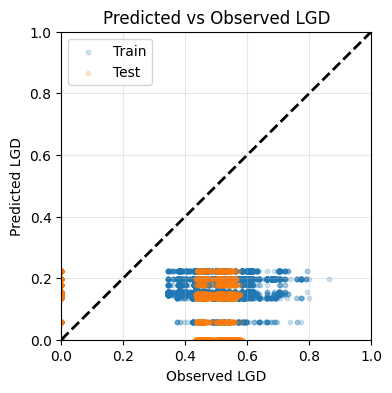

LGD estimation method: univariate
Feature: num__Interest


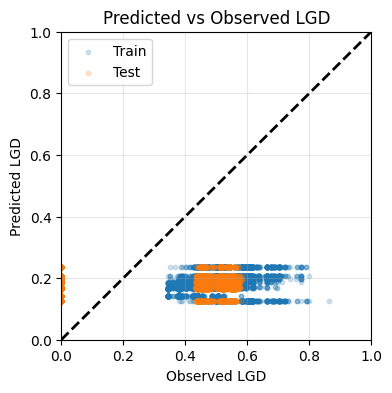

LGD estimation method: univariate
Feature: num__LoanDuration


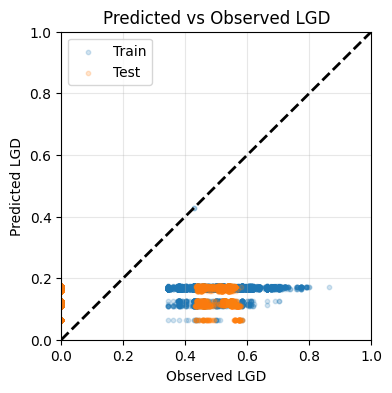

LGD estimation method: univariate
Feature: cat__Education


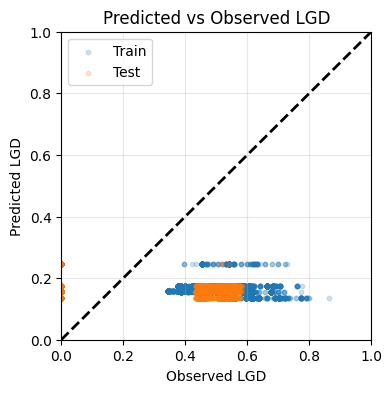

LGD estimation method: univariate
Feature: num__EmploymentDurationCurrentEmployer


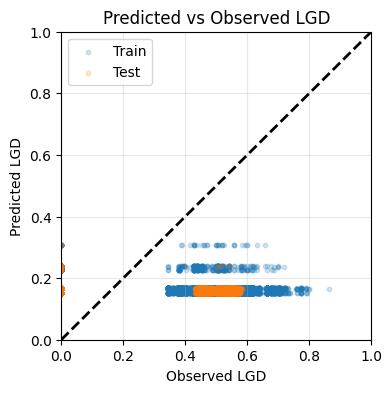

LGD estimation method: univariate
Feature: cat__HomeOwnershipType


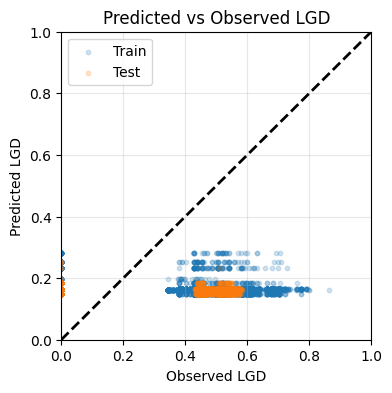

LGD estimation method: univariate
Feature: num__IncomeTotal


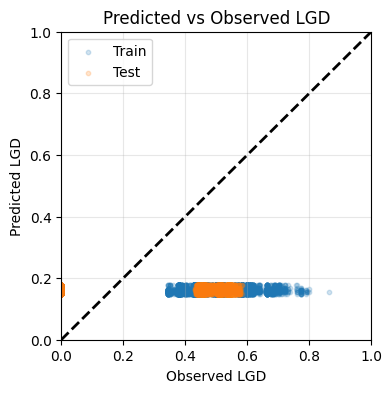

LGD estimation method: univariate
Feature: num__ExistingLiabilities


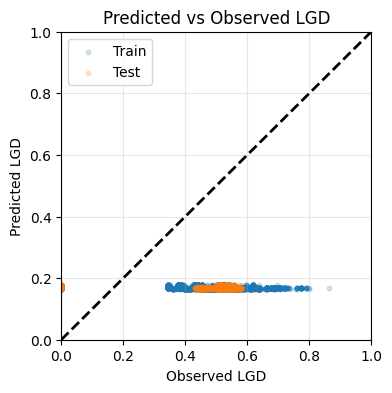

LGD estimation method: univariate
Feature: num__LiabilitiesTotal


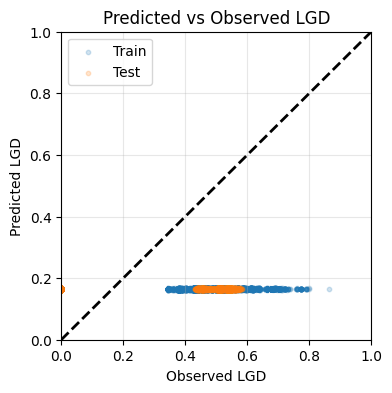

LGD estimation method: univariate
Feature: num__CreditScoreEeMini


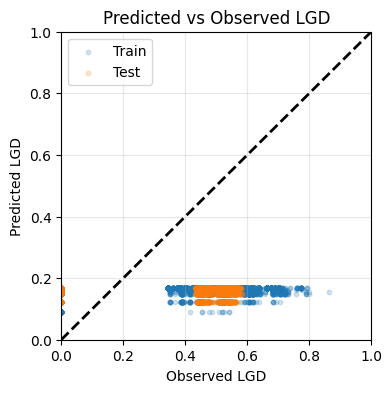

LGD estimation method: univariate
Feature: num__NoOfPreviousLoansBeforeLoan


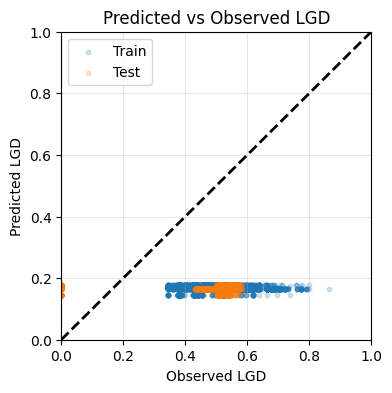

LGD estimation method: univariate
Feature: num__AmountOfPreviousLoansBeforeLoan


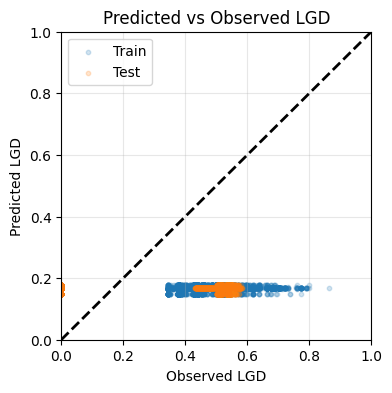

,Dataset,MAE,RMSE,CORR,R2,Experiment,Method,Variable
28,TRAIN,0.220063,0.238144,2.693805e-02,0.000593,experiment O,univariate,num__AmountOfPreviousLoansBeforeLoan
29,TEST,0.212418,0.226341,1.512574e-02,-0.018028,experiment O,univariate,num__AmountOfPreviousLoansBeforeLoan
26,TRAIN,0.220038,0.238098,3.422735e-02,0.000981,experiment N,univariate,num__NoOfPreviousLoansBeforeLoan
27,TEST,0.212327,0.226280,2.114028e-02,-0.017481,experiment N,univariate,num__NoOfPreviousLoansBeforeLoan
24,TRAIN,0.218799,0.238015,4.092642e-02,0.001675,experiment M,univariate,num__CreditScoreEeMini
25,TEST,0.211261,0.226769,-6.677684e-02,-0.021880,experiment M,univariate,num__CreditScoreEeMini
22,TRAIN,0.219736,0.238213,7.263948e-03,0.000017,experiment L,univariate,num__LiabilitiesTotal
23,TEST,0.211662,0.226118,-1.448513e-03,-0.016023,experiment L,univariate,num__LiabilitiesTotal
20,TRAIN,0.220822,0.238227,2.000090e-02,-0.000099,experiment K,univariate,num__ExistingLiabilities
21,TEST,0.213163,0.226640,-4.977496e-02,-0.020717,experiment K,univariate,num__ExistingLiabilities


In [14]:
# loop on experiments

for experiment, method, variable in experiments:

    # fit lgds on training dataset
    
    lgd_model = fit_lgd(ds_trai_emp, method=method, one_variable=variable)

    # transform lgds on training dataset 

    pred_trai   = transform_lgd(ds_trai_emp, lgd_model)

    # transform lgds on testing dataset

    pred_test   = transform_lgd(ds_test_emp, lgd_model)

    # evaluate: calculate metrics

    metrics_trai = my_regression_metrics(pred_trai["LossGivenDefault"], pred_trai["LGD"], dataset_name="TRAIN", verbose=False)   
    metrics_test = my_regression_metrics(pred_test["LossGivenDefault"], pred_test["LGD"], dataset_name="TEST" , verbose=False)   

    # append

    metrics_trai["Experiment"] = experiment
    metrics_trai["Dataset"]    = "TRAIN"
    metrics_trai["Method"]     = method
    metrics_trai["Variable"]   = variable
    experiment_metrics.append(metrics_trai)

    metrics_test["Experiment"] = experiment
    metrics_test["Dataset"]    = "TEST"
    metrics_test["Method"]     = method
    metrics_test["Variable"]   = variable
    experiment_metrics.append(metrics_test)

    # evaluate: visually
    
    pred_vs_obs_lgd(pred_trai, pred_test)

# put together

experiment_metrics_EMPIRICAL = pd.DataFrame(experiment_metrics)
display(experiment_metrics_EMPIRICAL.sort_values(by=["Experiment", "Dataset"], ascending=[False, False]))


#### Fit & Evaluate [model estimators]

In [15]:
# initialise experiments

experiments = [
    ("experiment P", "linear_regression", None),
    ("experiment Q", "gradient_boosting_regression", None),
]

experiment_metrics = []

LGD estimation method: linear_regression
cat__LanguageCode_6.0                    -0.263393
cat__Gender_1.0                          -0.165043
cat__HomeOwnershipType_6.0                0.077401
cat__LanguageCode_2.0                    -0.072109
cat__Education_2.0                        0.069318
cat__HomeOwnershipType_4.0                0.057689
cat__Education_5.0                        0.049553
cat__LanguageCode_4.0                     0.048374
cat__Education_4.0                        0.040666
cat__HomeOwnershipType_7.0                0.037771
num__Interest                             0.037215
cat__NewCreditCustomer_1.0               -0.026686
num__NoOfPreviousLoansBeforeLoan         -0.025893
cat__HomeOwnershipType_5.0                0.024930
num__ExistingLiabilities                  0.017798
num__Age                                  0.016372
num__CreditScoreEeMini                    0.015643
num__PreviousRepaymentsBeforeLoan        -0.015079
num__LoanDuration                        

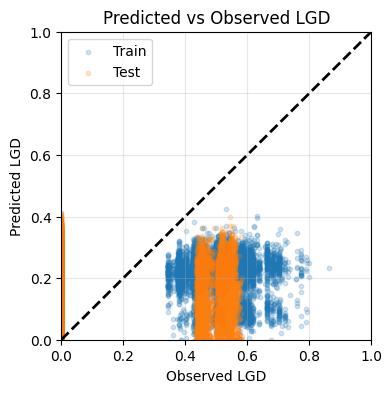

LGD estimation method: gradient_boosting_regression
cat__Gender_1.0                           0.197049
num__Amount                               0.072340
num__Interest                             0.060693
cat__Education_5.0                        0.043966
num__AmountOfPreviousLoansBeforeLoan      0.038840
num__PreviousRepaymentsBeforeLoan         0.036855
num__NoOfPreviousLoansBeforeLoan          0.035451
num__LoanDuration                         0.034542
cat__Education_2.0                        0.030949
num__CreditScoreEeMini                    0.027819
num__ExistingLiabilities                  0.027305
cat__Education_4.0                        0.025801
cat__NewCreditCustomer_1.0                0.024990
cat__Education_3.0                        0.024693
num__IncomeTotal                          0.023949
cat__VerificationType_4.0                 0.023811
cat__HomeOwnershipType_8.0                0.023130
cat__HomeOwnershipType_6.0                0.023019
num__LiabilitiesTotal         

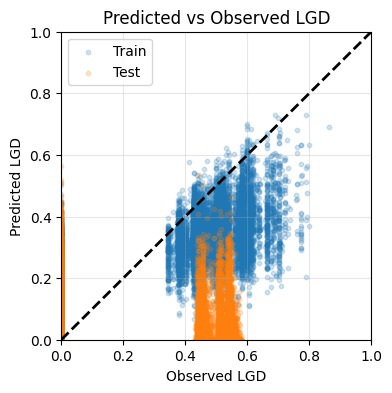

,Dataset,MAE,RMSE,CORR,R2,Experiment,Method,Variable
2,TRAIN,0.103591,0.144976,0.807851,0.629612,experiment Q,gradient_boosting_regression,None
3,TEST,0.158985,0.250249,0.020591,-0.244454,experiment Q,gradient_boosting_regression,None
0,TRAIN,0.185976,0.219278,0.391264,0.152672,experiment P,linear_regression,None
1,TEST,0.212733,0.250139,-0.084448,-0.243359,experiment P,linear_regression,None


In [16]:
# loop on experiments

for experiment, method, variable in experiments:

    # fit lgds on training dataset
    
    lgd_model = fit_lgd(ds_trai_mod, method=method, one_variable=variable)

    # transform lgds on training dataset 

    pred_trai   = transform_lgd(ds_trai_mod, lgd_model)

    # transform lgds on testing dataset

    pred_test   = transform_lgd(ds_test_mod, lgd_model)

    # evaluate: calculate metrics

    metrics_trai = my_regression_metrics(pred_trai["LossGivenDefault"], pred_trai["LGD"], dataset_name="TRAIN", verbose=False)   
    metrics_test = my_regression_metrics(pred_test["LossGivenDefault"], pred_test["LGD"], dataset_name="TEST" , verbose=False)   

    # append

    metrics_trai["Experiment"] = experiment
    metrics_trai["Dataset"]    = "TRAIN"
    metrics_trai["Method"]     = method
    metrics_trai["Variable"]   = variable
    experiment_metrics.append(metrics_trai)

    metrics_test["Experiment"] = experiment
    metrics_test["Dataset"]    = "TEST"
    metrics_test["Method"]     = method
    metrics_test["Variable"]   = variable
    experiment_metrics.append(metrics_test)

    # evaluate: visually
    
    pred_vs_obs_lgd(pred_trai, pred_test)

# put together

experiment_metrics_MODEL = pd.DataFrame(experiment_metrics)
display(experiment_metrics_MODEL.sort_values(by=["Experiment", "Dataset"], ascending=[False, False]))


#### Select & Export

In [17]:
# put together: EMPIRICAL, MODEL estimators

experiment_metrics_ALL = pd.concat([experiment_metrics_EMPIRICAL, experiment_metrics_MODEL], axis=0)

# model selector

selection_table, best_model = model_selector(experiment_metrics_ALL, metric="CORR")

display(selection_table)
display(best_model)

Dataset,Experiment,Method,Variable,Test CORR,Train CORR,Generalization Gap
0,experiment A,historical_avg,NaN,-5.369107e-15,1.810936e-15,7.180043e-15
1,experiment B,univariate,Age,-1.965199e-02,3.371288e-02,5.336488e-02
2,experiment C,univariate,Gender,1.590821e-02,3.262753e-01,3.103671e-01
3,experiment D,univariate,Amount,3.621250e-03,2.722665e-01,2.686452e-01
4,experiment E,univariate,Interest,1.016725e-01,1.572711e-01,5.559858e-02
5,experiment F,univariate,LoanDuration,-7.904517e-03,6.598860e-02,7.389311e-02
6,experiment G,univariate,Education,-1.385137e-02,6.693180e-02,8.078317e-02
7,experiment H,univariate,EmploymentDurationCurrentEmployer,-2.762621e-02,6.529829e-02,9.292450e-02
8,experiment I,univariate,HomeOwnershipType,-2.981702e-04,4.758348e-02,4.788165e-02
9,experiment J,univariate,IncomeTotal,-2.865296e-02,3.450498e-02,6.315793e-02


Dataset,Experiment,Method,Variable,Test CORR,Train CORR,Generalization Gap
4,experiment E,univariate,Interest,0.101673,0.157271,0.055599


In [18]:
# define LGD pipeline

#lgd_pipeline = {
#    "preprocessor": preprocessor_empirical,
#    "model": lgd_model
#}

In [19]:
# pipeline export

#import joblib
#joblib.dump(lgd_pipeline, "../models/PIPELINE_LGD_Amount.pkl")